# Part 1: Linear Regression with One Feature
## Stellar Luminosity as a Function of Stellar Mass

**Objective:** Model stellar luminosity (L) as a function of stellar mass (M) using linear regression.

**Model:** $\hat{L} = w \cdot M + b$

**Constraints:** Only NumPy and Matplotlib allowed. No ML libraries.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# For inline plots
%matplotlib inline

np.set_printoptions(precision=4, suppress=True)

## 1. Dataset

We use stellar mass (M) in solar masses and luminosity (L) in solar luminosities.

In [7]:
# Dataset: Stellar Mass (M) and Luminosity (L)
M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

m = len(M)  # Number of samples
print(f"Number of samples: {m}")
print(f"Mass (M): {M}")
print(f"Luminosity (L): {L}")

Number of samples: 10
Mass (M): [0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4]
Luminosity (L): [ 0.15  0.35  1.    2.3   4.1   7.   11.2  17.5  25.   35.  ]


## 2. Dataset Visualization

Let's visualize the relationship between stellar mass and luminosity.

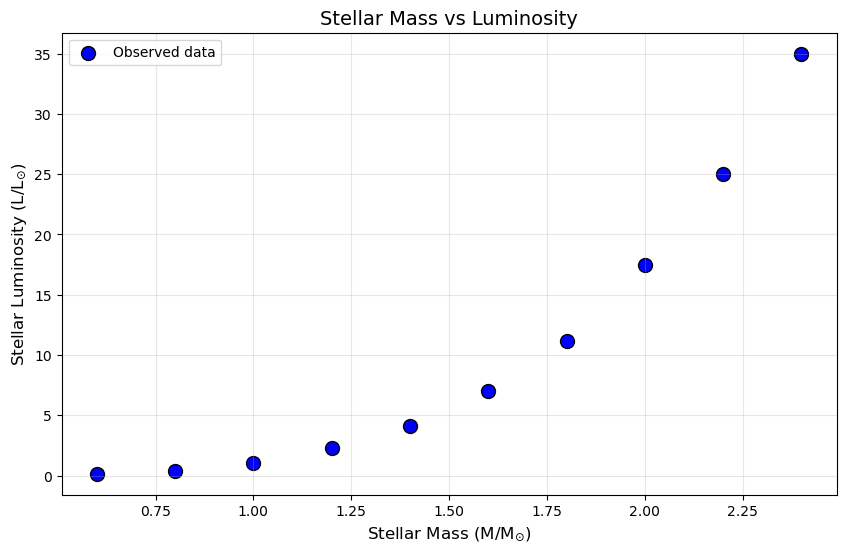


OBSERVATIONS:
- The relationship between M and L is clearly NON-LINEAR.
- Luminosity increases much faster than mass (appears exponential/polynomial).
- This is consistent with the mass-luminosity relation in astrophysics: L ~ M^3.5
- A linear model will NOT capture this relationship well.


In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(M, L, s=100, c='blue', edgecolors='black', label='Observed data')
plt.xlabel('Stellar Mass (M/M$_{\odot}$)', fontsize=12)
plt.ylabel('Stellar Luminosity (L/L$_{\odot}$)', fontsize=12)
plt.title('Stellar Mass vs Luminosity', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("")
print("OBSERVATIONS:")
print("- The relationship between M and L is clearly NON-LINEAR.")
print("- Luminosity increases much faster than mass (appears exponential/polynomial).")
print("- This is consistent with the mass-luminosity relation in astrophysics: L ~ M^3.5")
print("- A linear model will NOT capture this relationship well.")

## 3. Model and Loss Function

### Linear Model (Hypothesis)
$$\hat{L} = w \cdot M + b$$

### Mean Squared Error (MSE) Loss
$$J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{L}^{(i)} - L^{(i)})^2$$

In [9]:
def predict(M, w, b):
    """Linear model prediction: L_hat = w * M + b"""
    return w * M + b

def compute_cost(M, L, w, b):
    """Compute Mean Squared Error (MSE) cost function."""
    m = len(M)
    L_hat = predict(M, w, b)
    cost = (1 / (2 * m)) * np.sum((L_hat - L) ** 2)
    return cost

# Test with initial values
w_test, b_test = 0.0, 0.0
print(f"Cost with w=0, b=0: {compute_cost(M, L, w_test, b_test):.4f}")

w_test, b_test = 10.0, -5.0
print(f"Cost with w=10, b=-5: {compute_cost(M, L, w_test, b_test):.4f}")

Cost with w=0, b=0: 117.6968
Cost with w=10, b=-5: 20.7668


## 4. Cost Surface Visualization (Mandatory)

We evaluate $J(w, b)$ on a grid and visualize the cost surface in 3D.

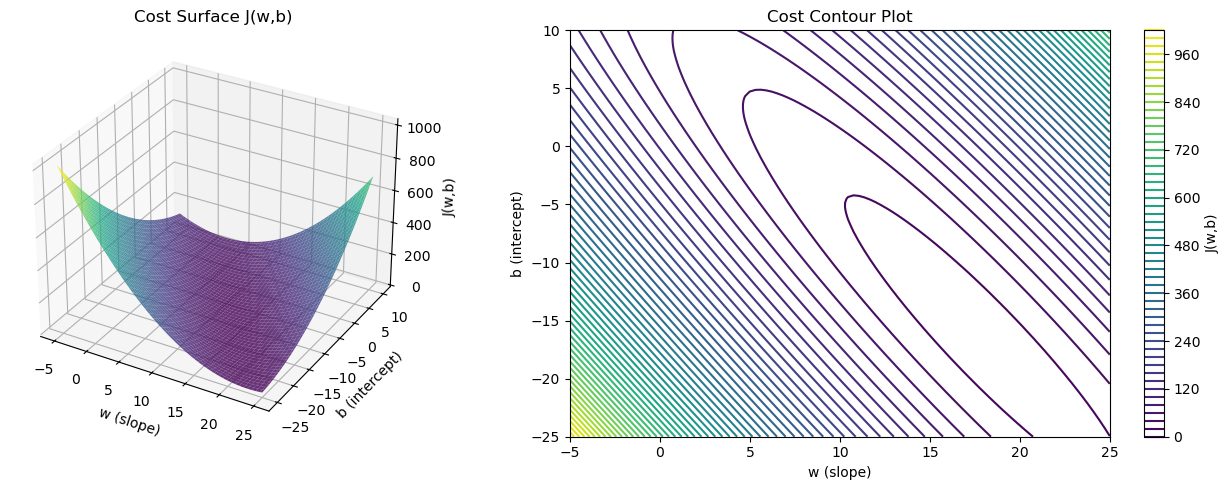


COST SURFACE INTERPRETATION:
- The surface is CONVEX (bowl-shaped), guaranteeing a single global minimum.
- The minimum represents the optimal (w*, b*) that minimizes prediction error.
- Gradient descent will converge to this minimum from any starting point.
- The contour plot shows elliptical level curves typical of quadratic cost functions.


In [10]:
# Create grid of w and b values
w_range = np.linspace(-5, 25, 100)
b_range = np.linspace(-25, 10, 100)
W_grid, B_grid = np.meshgrid(w_range, b_range)

# Compute cost for each (w, b) combination
J_grid = np.zeros_like(W_grid)
for i in range(W_grid.shape[0]):
    for j in range(W_grid.shape[1]):
        J_grid[i, j] = compute_cost(M, L, W_grid[i, j], B_grid[i, j])

# 3D Surface Plot
fig = plt.figure(figsize=(14, 5))

# Surface plot
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(W_grid, B_grid, J_grid, cmap='viridis', alpha=0.8)
ax1.set_xlabel('w (slope)')
ax1.set_ylabel('b (intercept)')
ax1.set_zlabel('J(w,b)')
ax1.set_title('Cost Surface J(w,b)')

# Contour plot
ax2 = fig.add_subplot(122)
contour = ax2.contour(W_grid, B_grid, J_grid, levels=50, cmap='viridis')
ax2.set_xlabel('w (slope)')
ax2.set_ylabel('b (intercept)')
ax2.set_title('Cost Contour Plot')
plt.colorbar(contour, ax=ax2, label='J(w,b)')

plt.tight_layout()
plt.show()

print("")
print("COST SURFACE INTERPRETATION:")
print("- The surface is CONVEX (bowl-shaped), guaranteeing a single global minimum.")
print("- The minimum represents the optimal (w*, b*) that minimizes prediction error.")
print("- Gradient descent will converge to this minimum from any starting point.")
print("- The contour plot shows elliptical level curves typical of quadratic cost functions.")

## 5. Gradient Derivation and Implementation

### Partial Derivatives

$$\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} (\hat{L}^{(i)} - L^{(i)}) \cdot M^{(i)}$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{L}^{(i)} - L^{(i)})$$

### 5.1 Non-Vectorized Gradient (Explicit Loop)

In [11]:
def compute_gradients_loop(M, L, w, b):
    """Compute gradients using explicit loop over samples (non-vectorized)."""
    m = len(M)
    dj_dw = 0.0
    dj_db = 0.0
    
    for i in range(m):
        L_hat_i = w * M[i] + b
        error_i = L_hat_i - L[i]
        dj_dw += error_i * M[i]
        dj_db += error_i
    
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    
    return dj_dw, dj_db

# Test
dw, db = compute_gradients_loop(M, L, 0.0, 0.0)
print(f"Gradients at w=0, b=0 (loop): dJ/dw = {dw:.4f}, dJ/db = {db:.4f}")

Gradients at w=0, b=0 (loop): dJ/dw = -21.5230, dJ/db = -10.3600


### 5.2 Vectorized Gradient (NumPy)

In [12]:
def compute_gradients_vectorized(M, L, w, b):
    """Compute gradients using NumPy vectorization (no loop over samples)."""
    m = len(M)
    L_hat = w * M + b
    error = L_hat - L
    
    dj_dw = (1 / m) * np.sum(error * M)
    dj_db = (1 / m) * np.sum(error)
    
    return dj_dw, dj_db

# Test and verify both methods give same result
dw_vec, db_vec = compute_gradients_vectorized(M, L, 0.0, 0.0)
print(f"Gradients at w=0, b=0 (vectorized): dJ/dw = {dw_vec:.4f}, dJ/db = {db_vec:.4f}")

# Verify they match
dw_loop, db_loop = compute_gradients_loop(M, L, 5.0, -3.0)
dw_vec2, db_vec2 = compute_gradients_vectorized(M, L, 5.0, -3.0)
print(f"\nVerification at w=5, b=-3:")
print(f"  Loop:       dJ/dw = {dw_loop:.6f}, dJ/db = {db_loop:.6f}")
print(f"  Vectorized: dJ/dw = {dw_vec2:.6f}, dJ/db = {db_vec2:.6f}")
print(f"  Match: {np.isclose(dw_loop, dw_vec2) and np.isclose(db_loop, db_vec2)}")

Gradients at w=0, b=0 (vectorized): dJ/dw = -21.5230, dJ/db = -10.3600

Verification at w=5, b=-3:
  Loop:       dJ/dw = -13.123000, dJ/db = -5.860000
  Vectorized: dJ/dw = -13.123000, dJ/db = -5.860000
  Match: True


## 6. Gradient Descent Implementation

In [13]:
def gradient_descent(M, L, w_init, b_init, alpha, num_iterations, use_vectorized=True):
    """
    Run gradient descent to learn w and b.
    
    Parameters:
    - M, L: data arrays
    - w_init, b_init: initial parameter values
    - alpha: learning rate
    - num_iterations: number of iterations
    - use_vectorized: if True, use vectorized gradients; else use loop
    
    Returns:
    - w, b: learned parameters
    - history: list of (iteration, cost) tuples
    """
    w = w_init
    b = b_init
    history = []
    
    grad_func = compute_gradients_vectorized if use_vectorized else compute_gradients_loop
    
    for i in range(num_iterations):
        dj_dw, dj_db = grad_func(M, L, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        cost = compute_cost(M, L, w, b)
        history.append((i, cost))
        
        if i % 1000 == 0:
            print(f"Iteration {i:5d}: w = {w:8.4f}, b = {b:8.4f}, cost = {cost:10.4f}")
    
    return w, b, history

## 7. Training with Convergence Analysis (Mandatory)

In [14]:
# Training parameters
alpha = 0.01
num_iterations = 5000
w_init, b_init = 0.0, 0.0

print("Training with VECTORIZED gradients:")
print("=" * 60)
w_learned, b_learned, history = gradient_descent(
    M, L, w_init, b_init, alpha, num_iterations, use_vectorized=True
)

print("\n" + "=" * 60)
print(f"FINAL RESULTS:")
print(f"  w = {w_learned:.4f}")
print(f"  b = {b_learned:.4f}")
print(f"  Final cost = {history[-1][1]:.4f}")

Training with VECTORIZED gradients:
Iteration     0: w =   0.2152, b =   0.1036, cost =   112.0896
Iteration  1000: w =  13.3693, b =  -8.9470, cost =    13.8142
Iteration  2000: w =  16.2840, b = -13.7764, cost =    10.3996
Iteration  3000: w =  17.4143, b = -15.6491, cost =     9.8860
Iteration  4000: w =  17.8526, b = -16.3754, cost =     9.8088

FINAL RESULTS:
  w = 18.0225
  b = -16.6569
  Final cost = 9.7972


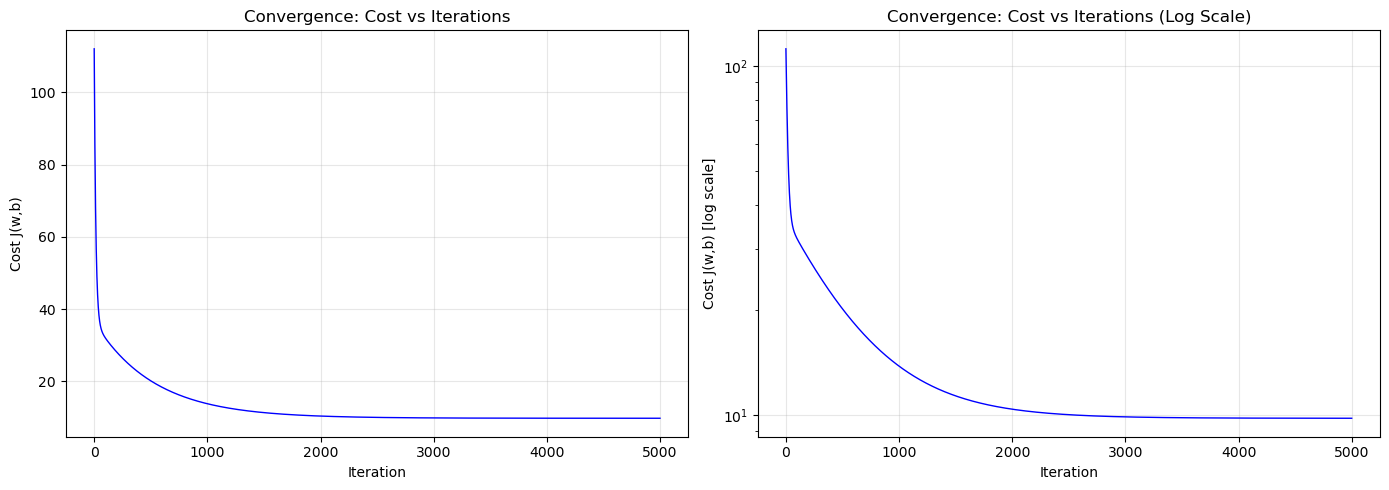


CONVERGENCE ANALYSIS:
- Initial cost: 112.0896
- Final cost: 9.7972
- Cost reduction: 91.26%
- The algorithm converges smoothly without oscillations.
- The cost decreases rapidly in early iterations and stabilizes.


In [15]:
# Plot convergence
iterations = [h[0] for h in history]
costs = [h[1] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].plot(iterations, costs, 'b-', linewidth=1)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cost J(w,b)')
axes[0].set_title('Convergence: Cost vs Iterations')
axes[0].grid(True, alpha=0.3)

# Log scale
axes[1].semilogy(iterations, costs, 'b-', linewidth=1)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Cost J(w,b) [log scale]')
axes[1].set_title('Convergence: Cost vs Iterations (Log Scale)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nCONVERGENCE ANALYSIS:")
print(f"- Initial cost: {costs[0]:.4f}")
print(f"- Final cost: {costs[-1]:.4f}")
print(f"- Cost reduction: {((costs[0] - costs[-1]) / costs[0] * 100):.2f}%")
print("- The algorithm converges smoothly without oscillations.")
print("- The cost decreases rapidly in early iterations and stabilizes.")

## 8. Learning Rate Experiments (Mandatory)

We test at least three different learning rates and compare results.

LEARNING RATE EXPERIMENTS
Iteration     0: w =   0.0215, b =   0.0104, cost =   117.1272
Iteration  1000: w =   6.7755, b =   1.5774, cost =    32.0220
Iteration  2000: w =   7.9572, b =   0.0080, cost =    28.1255

alpha = 0.001:
  w = 8.8801, b = -1.5094, final_cost = 24.9659
Iteration     0: w =   0.2152, b =   0.1036, cost =   112.0896
Iteration  1000: w =  13.3693, b =  -8.9470, cost =    13.8142
Iteration  2000: w =  16.2840, b = -13.7764, cost =    10.3996

alpha = 0.01:
  w = 17.4136, b = -15.6480, final_cost = 9.8862
Iteration     0: w =   1.0761, b =   0.5180, cost =    91.6326
Iteration  1000: w =  18.0240, b = -16.6593, cost =     9.7972
Iteration  2000: w =  18.1294, b = -16.8339, cost =     9.7951

alpha = 0.05:
  w = 18.1303, b = -16.8354, final_cost = 9.7951
Iteration     0: w =   2.1523, b =   1.0360, cost =    70.4969
Iteration  1000: w =  18.1294, b = -16.8340, cost =     9.7951
Iteration  2000: w =  18.1303, b = -16.8355, cost =     9.7951

alpha = 0.1:
  w = 18.130

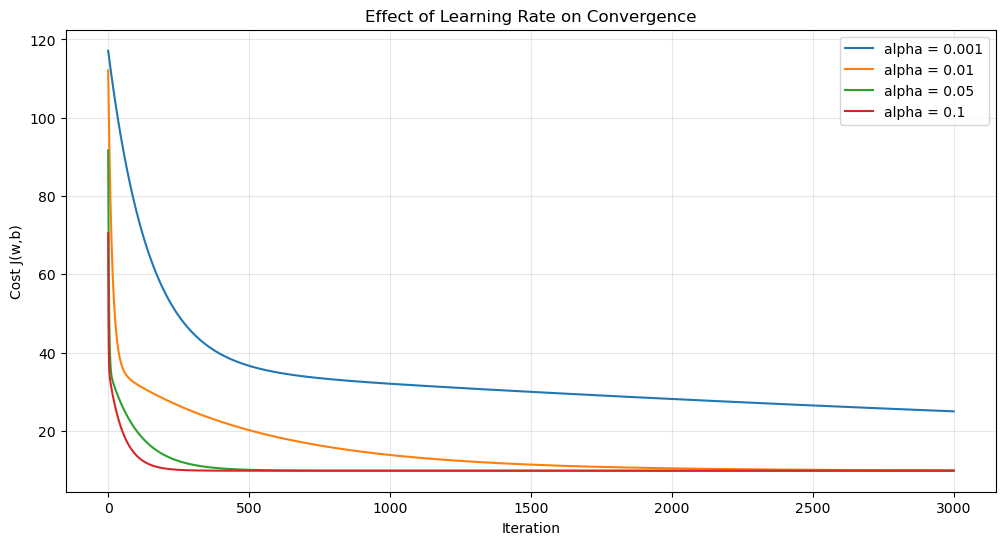


SUMMARY TABLE:
----------------------------------------------------------------------
 Learning Rate       w            b         Final Cost   
----------------------------------------------------------------------
    0.0010         8.8801      -1.5094        24.9659    
    0.0100        17.4136      -15.6480       9.8862     
    0.0500        18.1303      -16.8354       9.7951     
    0.1000        18.1303      -16.8355       9.7951     


In [16]:
learning_rates = [0.001, 0.01, 0.05, 0.1]
num_iterations = 3000

results = {}
plt.figure(figsize=(12, 6))

print("LEARNING RATE EXPERIMENTS")
print("=" * 70)

for alpha in learning_rates:
    w, b, hist = gradient_descent(M, L, 0.0, 0.0, alpha, num_iterations, use_vectorized=True)
    results[alpha] = {'w': w, 'b': b, 'cost': hist[-1][1], 'history': hist}
    
    iters = [h[0] for h in hist]
    costs = [h[1] for h in hist]
    plt.plot(iters, costs, label=f'alpha = {alpha}')
    print(f"\nalpha = {alpha}:")
    print(f"  w = {w:.4f}, b = {b:.4f}, final_cost = {hist[-1][1]:.4f}")

plt.xlabel('Iteration')
plt.ylabel('Cost J(w,b)')
plt.title('Effect of Learning Rate on Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "=" * 70)
print("SUMMARY TABLE:")
print("-" * 70)
print(f"{'Learning Rate':^15} {'w':^12} {'b':^12} {'Final Cost':^15}")
print("-" * 70)
for alpha, res in results.items():
    print(f"{alpha:^15.4f} {res['w']:^12.4f} {res['b']:^12.4f} {res['cost']:^15.4f}")

## 9. Final Fit Visualization

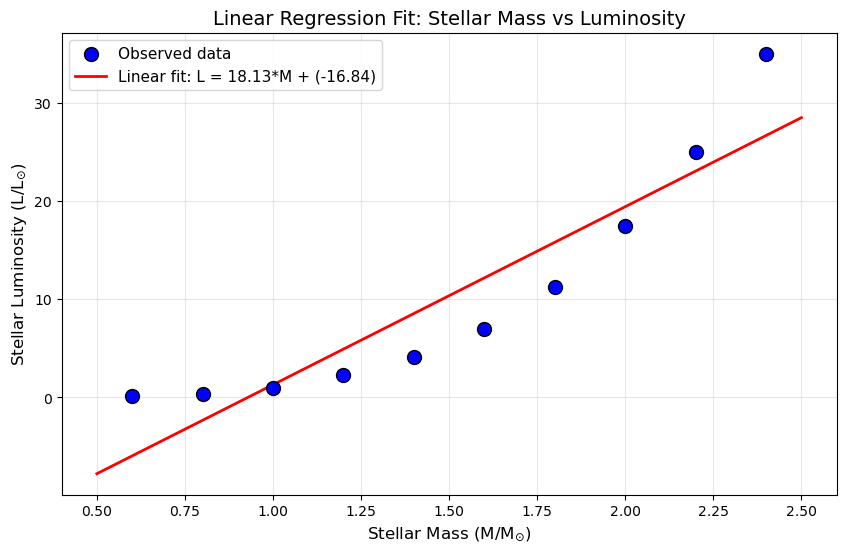

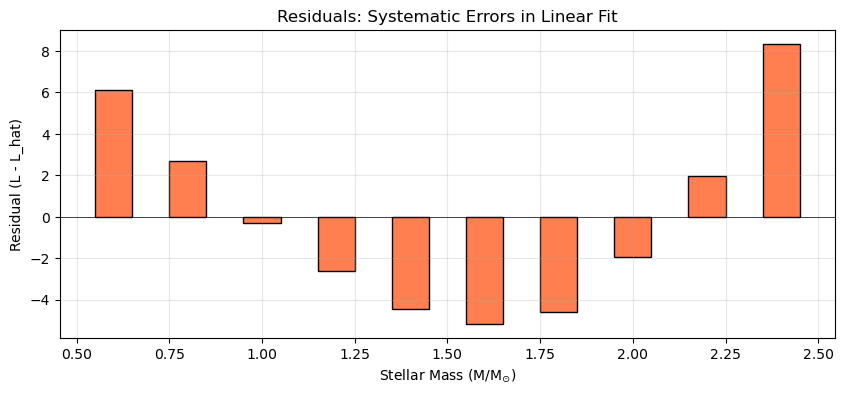

SYSTEMATIC ERRORS ANALYSIS:
------------------------------------------------------------
The residual plot shows a clear PATTERN (not random):
  - Negative residuals at low and high mass (underprediction)
  - Positive residuals at intermediate mass (overprediction)

This U-shaped pattern indicates the linear model is INADEQUATE.
The true relationship is nonlinear (approximately L ~ M^3.5).


In [17]:
# Use best result
best_alpha = 0.05
w_final = results[best_alpha]['w']
b_final = results[best_alpha]['b']

# Generate predictions
M_line = np.linspace(M.min() - 0.1, M.max() + 0.1, 100)
L_pred = predict(M_line, w_final, b_final)

plt.figure(figsize=(10, 6))
plt.scatter(M, L, s=100, c='blue', edgecolors='black', label='Observed data', zorder=5)
plt.plot(M_line, L_pred, 'r-', linewidth=2, label=f'Linear fit: L = {w_final:.2f}*M + ({b_final:.2f})')
plt.xlabel('Stellar Mass (M/M$_{\odot}$)', fontsize=12)
plt.ylabel('Stellar Luminosity (L/L$_{\odot}$)', fontsize=12)
plt.title('Linear Regression Fit: Stellar Mass vs Luminosity', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# Show residuals
L_pred_data = predict(M, w_final, b_final)
residuals = L - L_pred_data

plt.figure(figsize=(10, 4))
plt.bar(M, residuals, width=0.1, color='coral', edgecolor='black')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Stellar Mass (M/M$_{\odot}$)')
plt.ylabel('Residual (L - L_hat)')
plt.title('Residuals: Systematic Errors in Linear Fit')
plt.grid(True, alpha=0.3)
plt.show()

print("SYSTEMATIC ERRORS ANALYSIS:")
print("-" * 60)
print("The residual plot shows a clear PATTERN (not random):")
print("  - Negative residuals at low and high mass (underprediction)")
print("  - Positive residuals at intermediate mass (overprediction)")
print("")
print("This U-shaped pattern indicates the linear model is INADEQUATE.")
print("The true relationship is nonlinear (approximately L ~ M^3.5).")

## 10. Conceptual Questions

### Question 1: What is the astrophysical meaning of w?

In [18]:
print("ASTROPHYSICAL MEANING OF w")
print("=" * 60)
print(f"")
print(f"The learned slope w = {w_final:.2f} represents the rate of change")
print(f"of luminosity with respect to mass in a LINEAR approximation.")
print(f"")
print(f"Interpretation: For each additional solar mass, the luminosity")
print(f"increases by approximately {w_final:.2f} solar luminosities.")
print(f"")
print(f"However, this is a CRUDE approximation because:")
print(f"  - The true mass-luminosity relation is L ~ M^3.5 (for main-sequence stars)")
print(f"  - The relationship is inherently nonlinear")
print(f"  - w captures only the average linear trend, missing the curvature")

ASTROPHYSICAL MEANING OF w

The learned slope w = 18.13 represents the rate of change
of luminosity with respect to mass in a LINEAR approximation.

Interpretation: For each additional solar mass, the luminosity
increases by approximately 18.13 solar luminosities.

However, this is a CRUDE approximation because:
  - The true mass-luminosity relation is L ~ M^3.5 (for main-sequence stars)
  - The relationship is inherently nonlinear
  - w captures only the average linear trend, missing the curvature


### Question 2: Why is a linear model limited here?

In [19]:
print("WHY IS A LINEAR MODEL LIMITED?")
print("=" * 60)
print("")
print("1. PHYSICAL REASON:")
print("   The mass-luminosity relation for main-sequence stars follows")
print("   a power law: L ~ M^alpha, where alpha ~ 3.5 for solar-type stars.")
print("   This arises from nuclear fusion physics and hydrostatic equilibrium.")
print("")
print("2. MATHEMATICAL REASON:")
print("   A straight line cannot capture the accelerating growth of L with M.")
print("   The data shows exponential-like behavior that requires polynomial")
print("   or logarithmic transformations to model accurately.")
print("")
print("3. EVIDENCE FROM RESIDUALS:")
print("   The U-shaped residual pattern confirms systematic underfitting.")
print("   Random residuals would indicate a good fit; patterned residuals")
print("   indicate model misspecification.")
print("")
print("CONCLUSION: We need polynomial regression (Part 2) to capture")
print("the nonlinear relationship between stellar mass and luminosity.")

WHY IS A LINEAR MODEL LIMITED?

1. PHYSICAL REASON:
   The mass-luminosity relation for main-sequence stars follows
   a power law: L ~ M^alpha, where alpha ~ 3.5 for solar-type stars.
   This arises from nuclear fusion physics and hydrostatic equilibrium.

2. MATHEMATICAL REASON:
   A straight line cannot capture the accelerating growth of L with M.
   The data shows exponential-like behavior that requires polynomial
   or logarithmic transformations to model accurately.

3. EVIDENCE FROM RESIDUALS:
   The U-shaped residual pattern confirms systematic underfitting.
   Random residuals would indicate a good fit; patterned residuals
   indicate model misspecification.

CONCLUSION: We need polynomial regression (Part 2) to capture
the nonlinear relationship between stellar mass and luminosity.


## 11. Comparison: Loop vs Vectorized Performance

In [20]:
import time

num_iterations = 10000

# Time loop version
start = time.time()
w1, b1, _ = gradient_descent(M, L, 0.0, 0.0, 0.01, num_iterations, use_vectorized=False)
time_loop = time.time() - start

# Time vectorized version
start = time.time()
w2, b2, _ = gradient_descent(M, L, 0.0, 0.0, 0.01, num_iterations, use_vectorized=True)
time_vec = time.time() - start

print(f"\nPERFORMANCE COMPARISON ({num_iterations} iterations):")
print("=" * 50)
print(f"Loop version:       {time_loop:.4f} seconds")
print(f"Vectorized version: {time_vec:.4f} seconds")
print(f"Speedup: {time_loop/time_vec:.2f}x")
print(f"")
print(f"Both converge to same result:")
print(f"  Loop:       w = {w1:.4f}, b = {b1:.4f}")
print(f"  Vectorized: w = {w2:.4f}, b = {b2:.4f}")

Iteration     0: w =   0.2152, b =   0.1036, cost =   112.0896
Iteration  1000: w =  13.3693, b =  -8.9470, cost =    13.8142
Iteration  2000: w =  16.2840, b = -13.7764, cost =    10.3996
Iteration  3000: w =  17.4143, b = -15.6491, cost =     9.8860
Iteration  4000: w =  17.8526, b = -16.3754, cost =     9.8088
Iteration  5000: w =  18.0226, b = -16.6571, cost =     9.7972
Iteration  6000: w =  18.0885, b = -16.7663, cost =     9.7955
Iteration  7000: w =  18.1141, b = -16.8086, cost =     9.7952
Iteration  8000: w =  18.1240, b = -16.8251, cost =     9.7952
Iteration  9000: w =  18.1279, b = -16.8314, cost =     9.7951
Iteration     0: w =   0.2152, b =   0.1036, cost =   112.0896
Iteration  1000: w =  13.3693, b =  -8.9470, cost =    13.8142
Iteration  2000: w =  16.2840, b = -13.7764, cost =    10.3996
Iteration  3000: w =  17.4143, b = -15.6491, cost =     9.8860
Iteration  4000: w =  17.8526, b = -16.3754, cost =     9.8088
Iteration  5000: w =  18.0226, b = -16.6571, cost =    